# Capstone Two — EDA
### Predicting quality-control failures from in-process sensors (UCI SECOM)

**Question.** Can sensor readings taken during production predict which units fail final QC, and
which sensors carry that signal?

**Data.** Cleaned training partition: 1,253 units, 436 sensors, 28 missing-value flags, 6.9% failures.
The 314 test units are untouched — inspecting them is leakage even with no model fitted.

**Contents.** §2 feature profiles · §3 inferential statistics · §4 visualisation ·
§5 correlation structure · §6 saved outputs · §7 summary.

**Scope.** This notebook describes the data; it does not select features. Selection uses the labels,
so it belongs inside the modelling notebook's cross-validation loop, not here.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 10})
pd.set_option("display.max_columns", 30, "display.width", 150)

DATA = OUT = Path("../outputs")
ALPHA = 0.05

train = pd.read_csv(DATA / "secom_train_clean.csv", parse_dates=["timestamp"])
SENSORS = [c for c in train.columns if c.startswith("S") and not c.endswith("_isna")]
FLAGS   = [c for c in train.columns if c.endswith("_isna")]
y = train["fail"]

print(f"{len(train):,} units | {len(SENSORS)} sensors | {len(FLAGS)} flags | "
      f"{y.sum()} failures ({y.mean():.1%})")

1,253 units | 436 sensors | 28 flags | 87 failures (6.9%)


## 2. Feature profiles

436 sensors is too many to plot individually, so all are profiled numerically and the *distribution
of those profiles* is plotted.

In [2]:
# Full numeric profile: one row per sensor, computed across all 436
prof = pd.DataFrame({
    "mean":     train[SENSORS].mean(),
    "median":   train[SENSORS].median(),
    "std":      train[SENSORS].std(),
    "min":      train[SENSORS].min(),
    "max":      train[SENSORS].max(),
    "skew":     train[SENSORS].skew(),
    "kurtosis": train[SENSORS].kurtosis(),
    "n_unique": train[SENSORS].nunique(),
})
prof["cv"] = (prof["std"] / prof["mean"].abs()).replace([np.inf, -np.inf], np.nan)

print(f"profiled {len(prof)} sensors\n")
print(prof[["mean", "std", "skew", "kurtosis", "cv"]].describe().round(3).to_string())
prof.head(8).round(3)

profiled 436 sensors

           mean       std     skew  kurtosis       cv
count   436.000   436.000  436.000   436.000  436.000
mean    112.467    71.360    1.451     9.286    2.202
std     702.171   436.055    2.409    20.871   13.854
min   -5639.632     0.000  -11.478    -1.427    0.002
25%       0.105     0.039    0.111     0.084    0.201
50%       2.640     0.718    0.833     1.354    0.392
75%      19.909     5.861    2.038     6.477    0.653
max    8818.563  6320.568   10.946   133.658  202.390


,mean,median,std,min,max,skew,kurtosis,n_unique,cv
S000,3014.389,3012.090,68.137,2830.378,3232.006,0.353,0.699,1215,0.023
S001,2495.180,2498.840,80.604,2238.932,2738.270,-0.157,1.246,1195,0.032
S002,2200.272,2200.133,30.621,2074.289,2276.456,-0.319,1.101,419,0.014
S003,1384.457,1288.086,380.416,861.804,2490.695,0.755,-0.218,427,0.275
S004,1.295,1.298,0.367,0.722,3.502,1.470,6.371,417,0.284
S006,101.115,101.833,4.846,85.428,111.549,-0.939,1.268,421,0.048
S007,0.122,0.122,0.002,0.117,0.128,0.020,-0.280,82,0.016
S008,1.471,1.468,0.068,1.311,1.637,0.099,-0.530,987,0.046


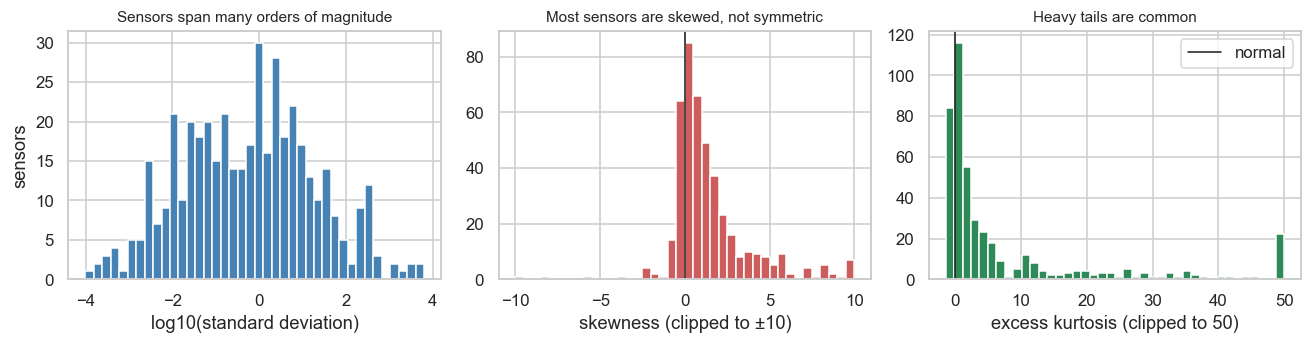

sensors with |skew| > 2      : 118 of 436
sensors with kurtosis > 10   : 96
std ranges from 9.84e-05 to 6.32e+03


In [3]:
# How are the sensors distributed in shape and scale?
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))

ax[0].hist(np.log10(prof["std"].replace(0, np.nan).dropna()), bins=40, color="steelblue")
ax[0].set_xlabel("log10(standard deviation)"); ax[0].set_ylabel("sensors")
ax[0].set_title("Sensors span many orders of magnitude")

ax[1].hist(prof["skew"].clip(-10, 10), bins=40, color="indianred")
ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("skewness (clipped to ±10)")
ax[1].set_title("Most sensors are skewed, not symmetric")

ax[2].hist(prof["kurtosis"].clip(-5, 50), bins=40, color="seagreen")
ax[2].axvline(0, color="k", lw=1, label="normal")
ax[2].set_xlabel("excess kurtosis (clipped to 50)")
ax[2].set_title("Heavy tails are common"); ax[2].legend()
plt.tight_layout(); plt.show()

print(f"sensors with |skew| > 2      : {(prof['skew'].abs() > 2).sum()} of {len(prof)}")
print(f"sensors with kurtosis > 10   : {(prof['kurtosis'] > 10).sum()}")
print(f"std ranges from {prof['std'].min():.2e} to {prof['std'].max():.2e}")

Two facts that drive everything downstream: SDs span orders of magnitude, so scaling must happen
inside the pipeline; and most sensors are skewed with heavy tails, so §3 uses a rank-based test and
never needs a normality check.

### 2.1 Response variable

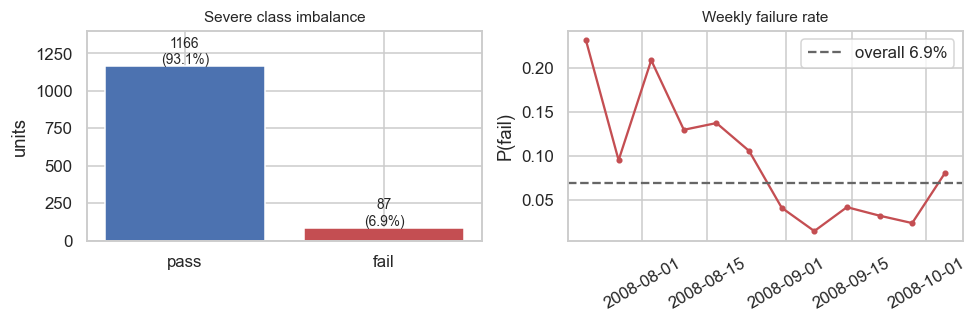

imbalance ratio: 13.4 passes per failure


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
counts = y.value_counts().sort_index()
ax[0].bar(["pass", "fail"], counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 15, f"{v}\n({v/len(y):.1%})", ha="center", fontsize=9)
ax[0].set_ylabel("units"); ax[0].set_title("Severe class imbalance")
ax[0].set_ylim(0, counts.max() * 1.2)

monthly = train.set_index("timestamp").resample("W")["fail"].mean()
ax[1].plot(monthly.index, monthly.values, marker="o", ms=3, color="#C44E52")
ax[1].axhline(y.mean(), ls="--", color="0.4", label=f"overall {y.mean():.1%}")
ax[1].set_title("Weekly failure rate"); ax[1].set_ylabel("P(fail)")
ax[1].tick_params(axis="x", rotation=30); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"imbalance ratio: {(1-y).sum() / y.sum():.1f} passes per failure")

Imbalance is the dataset's defining feature. Accuracy is useless (always-pass scores 93.1%), so
PR-AUC and recall are the metrics that matter. Power is limited by the 87 failures, not the 1,253
units — every test below is effectively small-sample. Failures also cluster in time, so validation
must be time-ordered.

## 3. Inferential statistics

**Hypotheses**, for each sensor $j$:

> $H_0$: sensor $j$ has the same distribution in failing and passing units.
> $H_1$: the distributions differ.

**Statistic: per-sensor AUC** $= P(X_\text{fail} > X_\text{pass})$. 0.5 means no separation, 1.0
perfect. It needs no interpretation table and is the metric the modelling notebook reports, so the
best single sensor becomes the bar a fitted model must clear.

**Test: Mann-Whitney U**, which *is* AUC rescaled — $\text{AUC} = U/(n_1n_2)$ — so one call gives
both the effect and its p-value. It is distribution-free, which matters given §2's skew, but not
assumption-free: its null is that the distributions are *identical*, so a rejection can come from
spread as well as location. §4 tells those apart.

**Multiple comparisons.** Benjamini-Hochberg FDR holds the expected false-discovery proportion at α
(constant sensors are skipped — no hypothesis to test). BH over Bonferroni for power; it is valid
under the positive dependence §5 finds. A permutation null in the second cell checks the same thing
without assuming any formula.

In [5]:
fail_mask = y == 1
rows, skipped = [], []
for s in SENSORS:
    a, b = train.loc[fail_mask, s], train.loc[~fail_mask, s]
    if a.nunique() <= 1 and b.nunique() <= 1:
        skipped.append(s)                      # constant everywhere: nothing to test
        continue

    # scipy returns U for the FIRST sample, so U/(n1*n2) is P(fail > pass) directly.
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    auc = u / (len(a) * len(b))

    rows.append({"sensor": s, "auc": auc,
                 "median_fail": a.median(), "median_pass": b.median(),
                 "p": p})

tests = pd.DataFrame(rows)
# Benjamini-Hochberg FDR correction
tests["p_fdr"] = stats.false_discovery_control(
    tests["p"].to_numpy(),
    method="bh"
)

tests["auc_signed"] = (tests.auc - 0.5).abs()   # distance from no-signal, direction-free
tests = tests.sort_values(["p_fdr", "auc_signed"], ascending=[True, False]).reset_index(drop=True)

n_sig, n_raw = int((tests.p_fdr < ALPHA).sum()), int((tests.p < ALPHA).sum())
n_chance = ALPHA * len(tests)
best = tests.loc[tests.auc_signed.idxmax()]

print(f"sensors offered / constant-skipped / tested : "
      f"{len(SENSORS)} / {len(skipped)} / {len(tests)}")
print(f"\nsignificant after FDR (< {ALPHA})              : {n_sig}")
print(f"uncorrected p < {ALPHA}                        : {n_raw}"
      f"   (~{n_chance:.0f} expected by chance)   ratio {n_raw/n_chance:.2f}x")
print(f"\nbest single sensor  : {best.sensor}   AUC = {best.auc:.3f}")
print(f"median AUC distance from 0.5 across sensors : {tests.auc_signed.median():.3f}")

sensors offered / constant-skipped / tested : 436 / 0 / 436

significant after FDR (< 0.05)              : 20
uncorrected p < 0.05                        : 70   (~22 expected by chance)   ratio 3.21x

best single sensor  : S059   AUC = 0.728
median AUC distance from 0.5 across sensors : 0.024


In [6]:
sig = tests[tests.p_fdr < ALPHA]
print(f"Sensors significant after FDR correction: {len(sig)} of {len(tests)}\n")
display(sig.head(15)[["sensor", "auc", "median_fail", "median_pass", "p_fdr"]].round(4))

print("Read AUC as: a failing unit reads higher than a passing one this often.")
print(f"e.g. {sig.iloc[0].sensor}: {sig.iloc[0].auc:.1%} of failure/pass pairs.")

Sensors significant after FDR correction: 20 of 436



,sensor,auc,median_fail,median_pass,p_fdr
0,S059,0.7281,8.5273,1.1677,0.0000
1,S247,0.6556,0.0343,0.0274,0.0002
2,S519,0.6511,7.3813,5.9227,0.0002
3,S103,0.6458,-0.0081,-0.0099,0.0006
4,S510,0.6312,61.3699,48.1474,0.0036
5,S477,0.6300,6.3640,5.2977,0.0036
6,S205,0.6290,9.3300,7.8200,0.0036
7,S290,0.6276,0.1166,0.0833,0.0038
8,S341,0.6246,2.7764,2.4068,0.0050
9,S385,0.6194,0.0072,0.0068,0.0064


Read AUC as: a failing unit reads higher than a passing one this often.
e.g. S059: 72.8% of failure/pass pairs.


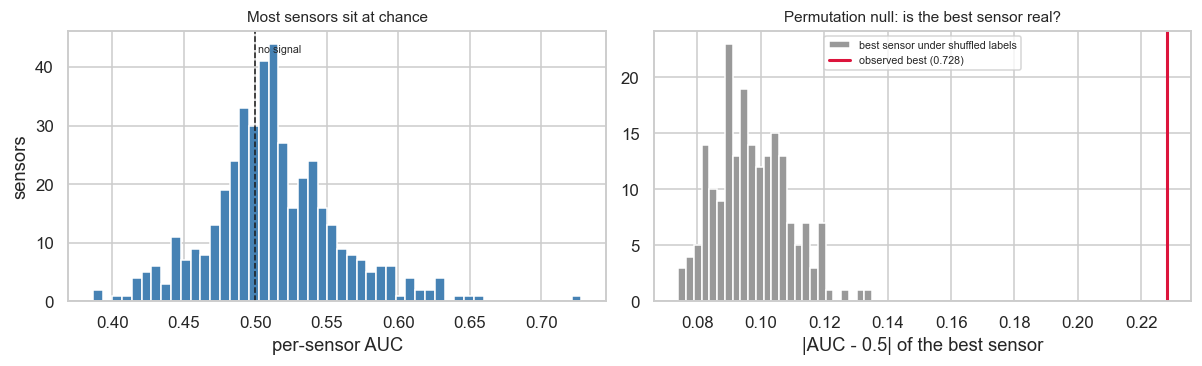

best sensor under 200 label shuffles : 0.597 average, 0.635 max
observed best                          : 0.728
permutation p-value (whole-screen)     : 0.000


In [7]:
# A permutation null answers the multiple-comparisons question directly: if the labels
# carried no information at all, how good would the BEST of these sensors look anyway?
rng = np.random.default_rng(0)
N_PERM = 200
X_ranked = train[tests.sensor].rank().to_numpy()      # rank once, reuse every shuffle
n1 = int(y.sum())

null_best = np.empty(N_PERM)
for k in range(N_PERM):
    idx = rng.permutation(len(train))[:n1]            # random "failures"
    u_perm = X_ranked[idx].sum(axis=0) - n1 * (n1 + 1) / 2
    auc_perm = u_perm / (n1 * (len(train) - n1))
    null_best[k] = np.abs(auc_perm - 0.5).max()

observed_best = tests.auc_signed.max()
p_global = (null_best >= observed_best).mean()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))

ax[0].hist(tests.auc, bins=50, color="steelblue")
ax[0].axvline(0.5, ls="--", color="k", lw=1)
ax[0].text(0.5, ax[0].get_ylim()[1]*0.92, " no signal", fontsize=7)
ax[0].set_xlabel("per-sensor AUC"); ax[0].set_ylabel("sensors")
ax[0].set_title("Most sensors sit at chance")

ax[1].hist(null_best, bins=25, color="0.6", label="best sensor under shuffled labels")
ax[1].axvline(observed_best, color="crimson", lw=2,
              label=f"observed best ({observed_best + 0.5:.3f})")
ax[1].set_xlabel("|AUC - 0.5| of the best sensor")
ax[1].set_title("Permutation null: is the best sensor real?")
ax[1].legend(fontsize=7)

plt.tight_layout(); plt.show()

print(f"best sensor under {N_PERM} label shuffles : "
      f"{null_best.mean() + 0.5:.3f} average, {null_best.max() + 0.5:.3f} max")
print(f"observed best                          : {observed_best + 0.5:.3f}")
print(f"permutation p-value (whole-screen)     : {p_global:.3f}")

Read three numbers: the **best AUC** against 0.5; the **uncorrected-to-chance ratio** (near 1 = noise,
well above 1 = real signal); and the **permutation p-value**, which rebuilds the whole screen on
shuffled labels and asks how often chance produces a winner this good.

The picture is weak but real signal — some sensors clear FDR and the best beats the permutation null,
yet AUC piles up at 0.5 and even the best leaves the classes heavily overlapped. **No single sensor
separates failures from passes.** A model must pool weak signals across many sensors, which points to
regularised linear models and tree ensembles, not a simple rule.

### 3.1 Missing-value flags

No test needed: flag and failure are both binary, so the **failure-rate lift** answers the question
directly and more interpretably than a chi-square p-value would.

In [8]:
flag_rows = []
for f in FLAGS:
    n_missing = int(train[f].sum())
    if n_missing == 0 or n_missing == len(train):
        continue
    rate_missing = y[train[f] == 1].mean()
    rate_present = y[train[f] == 0].mean()
    flag_rows.append({"flag": f, "n_missing": n_missing,
                      "fail_rate_missing": rate_missing,
                      "fail_rate_present": rate_present,
                      "lift": rate_missing / rate_present if rate_present else np.nan})

flags_df = (pd.DataFrame(flag_rows)
              .sort_values("lift", ascending=False)
              .reset_index(drop=True))

print(f"missing-indicators profiled : {len(flags_df)}")
print(f"overall failure rate        : {y.mean():.1%}\n")
display(flags_df.head(8).round(4))

missing-indicators profiled : 28
overall failure rate        : 6.9%



,flag,n_missing,fail_rate_missing,fail_rate_present,lift
0,S566_isna,272,0.0882,0.0642,1.3739
1,S567_isna,272,0.0882,0.0642,1.3739
2,S568_isna,272,0.0882,0.0642,1.3739
3,S569_isna,272,0.0882,0.0642,1.3739
4,S562_isna,272,0.0882,0.0642,1.3739
5,S563_isna,272,0.0882,0.0642,1.3739
6,S564_isna,272,0.0882,0.0642,1.3739
7,S565_isna,272,0.0882,0.0642,1.3739


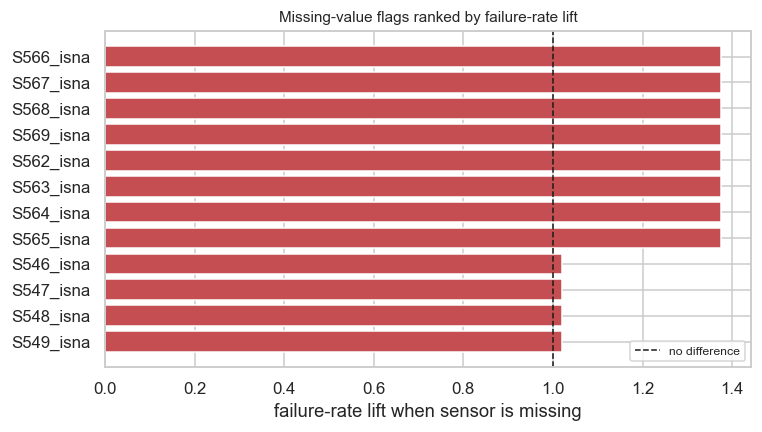

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
top = flags_df.head(12).iloc[::-1]
ax.barh(top.flag, top.lift, color="#C44E52")
ax.axvline(1, ls="--", color="k", lw=1, label="no difference")
ax.set_xlabel("failure-rate lift when sensor is missing")
ax.set_title("Missing-value flags ranked by failure-rate lift", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Where a flag shows lift, the sensor going offline travels with failure — plausibly the same fault
causes both. That is why wrangling kept the indicators instead of silently imputing. Whether they
survive conditioning on the sensors is a modelling question; EDA establishes only that they are not
inert.

## 4. Visualisation

§3 said *which* sensors differ. Plots say *how* — and guard against a significant result produced by
a few outliers rather than a genuine shift.

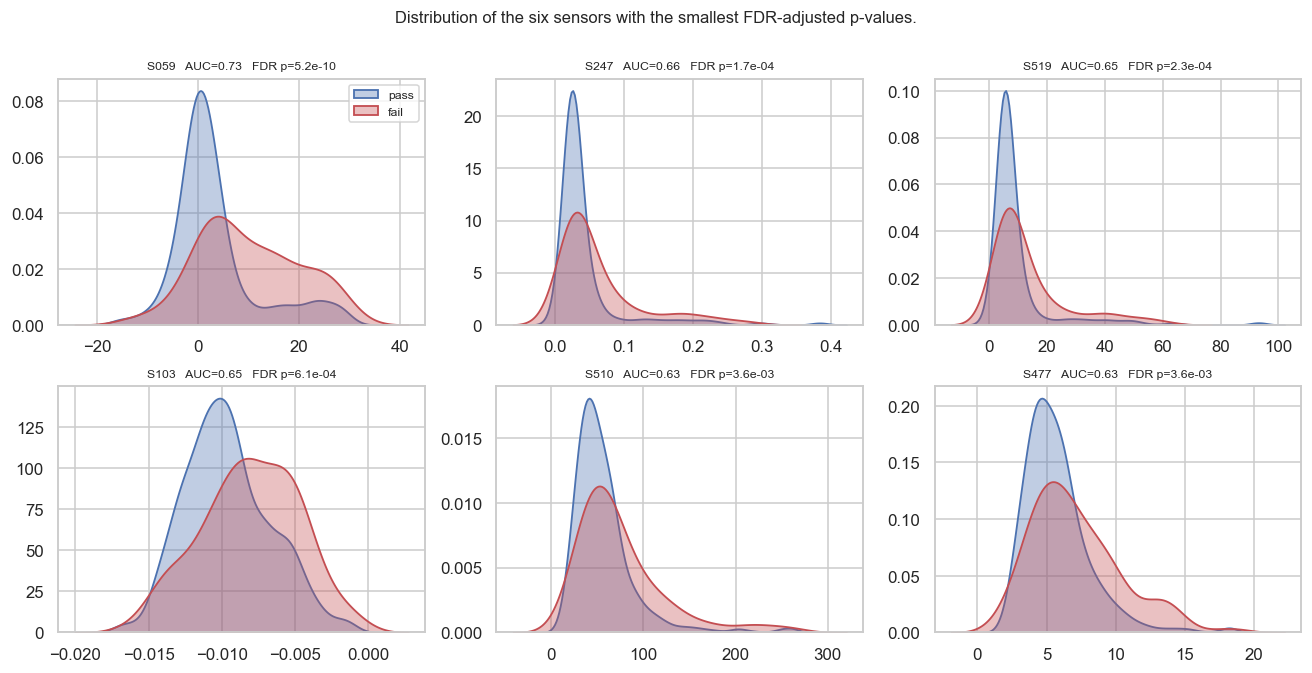

In [10]:
top6 = (tests.sort_values(["p_fdr", "auc_signed"], ascending=[True, False])
           .head(6).sensor.tolist())

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, s in zip(axes.ravel(), top6):
    for lab, colour in [(0, "#4C72B0"), (1, "#C44E52")]:
        sns.kdeplot(train.loc[y == lab, s], ax=ax, fill=True, alpha=0.35,
                    color=colour, label="fail" if lab else "pass", lw=1.2)
    r = tests.loc[tests.sensor == s].iloc[0]
    ax.set_title(f"{s}   AUC={r.auc:.2f}   FDR p={r.p_fdr:.1e}",
                 fontsize=8)
    ax.set_xlabel(""); ax.set_ylabel("")
axes[0, 0].legend(fontsize=8)
plt.suptitle("Distribution of the six sensors with the smallest FDR-adjusted p-values.", y=1.01)
plt.tight_layout(); plt.show()

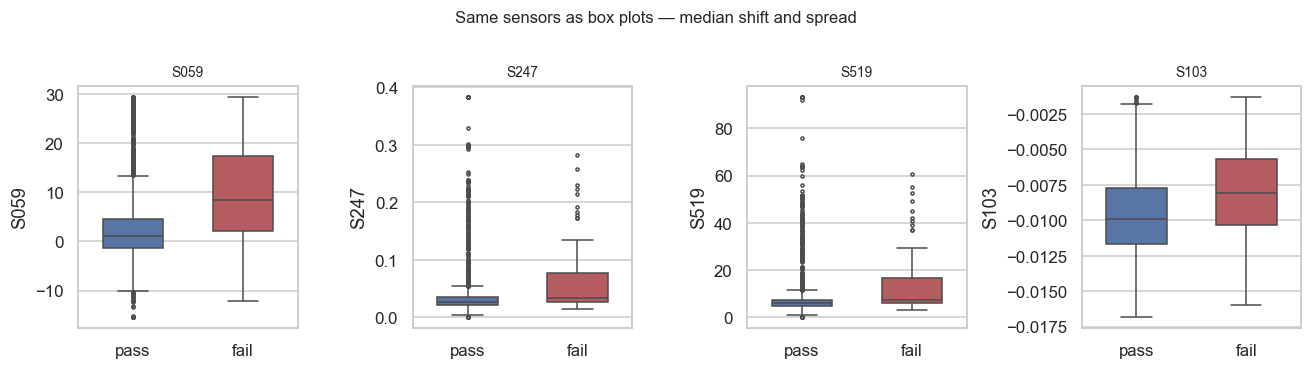

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, s in zip(axes, top6[:4]):
    sns.boxplot(x=y.map({0: "pass", 1: "fail"}), y=train[s], ax=ax,
                palette=["#4C72B0", "#C44E52"], width=0.55, fliersize=2)
    ax.set_title(s, fontsize=9); ax.set_xlabel("")
plt.suptitle("Same sensors as box plots — median shift and spread", y=1.03)
plt.tight_layout(); plt.show()

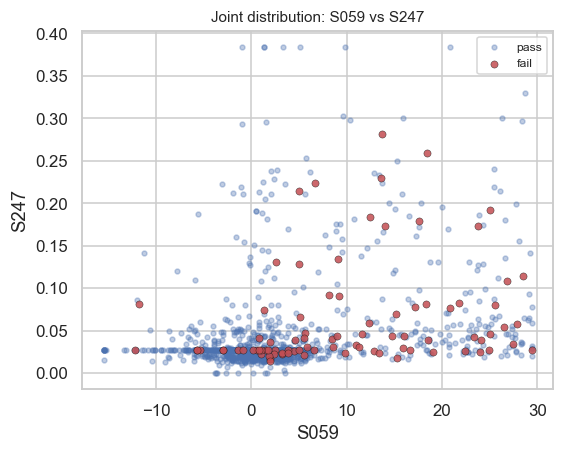

failures falling inside the central 90% range of BOTH sensors: 72.4%
(high = failures sit inside the passing cloud, so no two-sensor rule separates them)


In [12]:
# Bi-plot: do two weak sensors separate the classes better together than alone?
s1, s2 = top6[0], top6[1]
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.scatter(train.loc[y == 0, s1], train.loc[y == 0, s2], s=10, alpha=0.35,
           color="#4C72B0", label="pass")
ax.scatter(train.loc[y == 1, s1], train.loc[y == 1, s2], s=22, alpha=0.85,
           color="#C44E52", edgecolor="k", linewidth=0.3, label="fail")
ax.set_xlabel(s1); ax.set_ylabel(s2)
ax.set_title(f"Joint distribution: {s1} vs {s2}")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# What to look for: a distinct region occupied by failures would mean a two-sensor rule
# could work. Scatter through the passing cloud means it cannot.
hull_frac = ((train.loc[y == 1, s1].between(*train.loc[y == 0, s1].quantile([.05, .95]))) &
             (train.loc[y == 1, s2].between(*train.loc[y == 0, s2].quantile([.05, .95])))).mean()
print(f"failures falling inside the central 90% range of BOTH sensors: {hull_frac:.1%}")
print("(high = failures sit inside the passing cloud, so no two-sensor rule separates them)")

Failures are shifted **and** more dispersed, not merely shifted — which is exactly the ambiguity in
Mann-Whitney's null. If instability rather than level is the failure signature, engineered features
like |z-score| or rolling SD may separate better than raw readings. The bi-plot shows failures
scattered through the passing cloud: no two-sensor rule will work.

## 5. Correlation structure

In [30]:
corr = train[SENSORS].corr()
abs_corr = corr.abs().mask(np.eye(len(SENSORS), dtype=bool))   # blank the diagonal

pairs = (abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
                 .stack().sort_values(ascending=False))

print("Pairwise |Pearson r| among 436 sensors")
print(f"  pairs                : {len(pairs):,}")
print(f"  median |r|           : {pairs.median():.3f}")
for t in [0.7, 0.8, 0.9, 0.95]:
    print(f"  pairs with |r| > {t}  : {(pairs > t).sum():,}")
print(f"\nsensors with at least one partner above 0.9: "
      f"{(abs_corr.max() > 0.9).sum()} of {len(SENSORS)}")
print("\nStrongest pairs:")
display(pairs.head(8).to_frame("abs_r").round(4))

Pairwise |Pearson r| among 436 sensors
  pairs                : 94,830
  median |r|           : 0.030
  pairs with |r| > 0.7  : 497
  pairs with |r| > 0.8  : 400
  pairs with |r| > 0.9  : 288
  pairs with |r| > 0.95  : 216

sensors with at least one partner above 0.9: 298 of 436

Strongest pairs:


,,abs_r
S254,S526,1.0000
S251,S523,1.0000
S222,S494,1.0000
S155,S428,1.0000
S153,S426,0.9999
S176,S447,0.9999
S268,S540,0.9999
S195,S467,0.9999


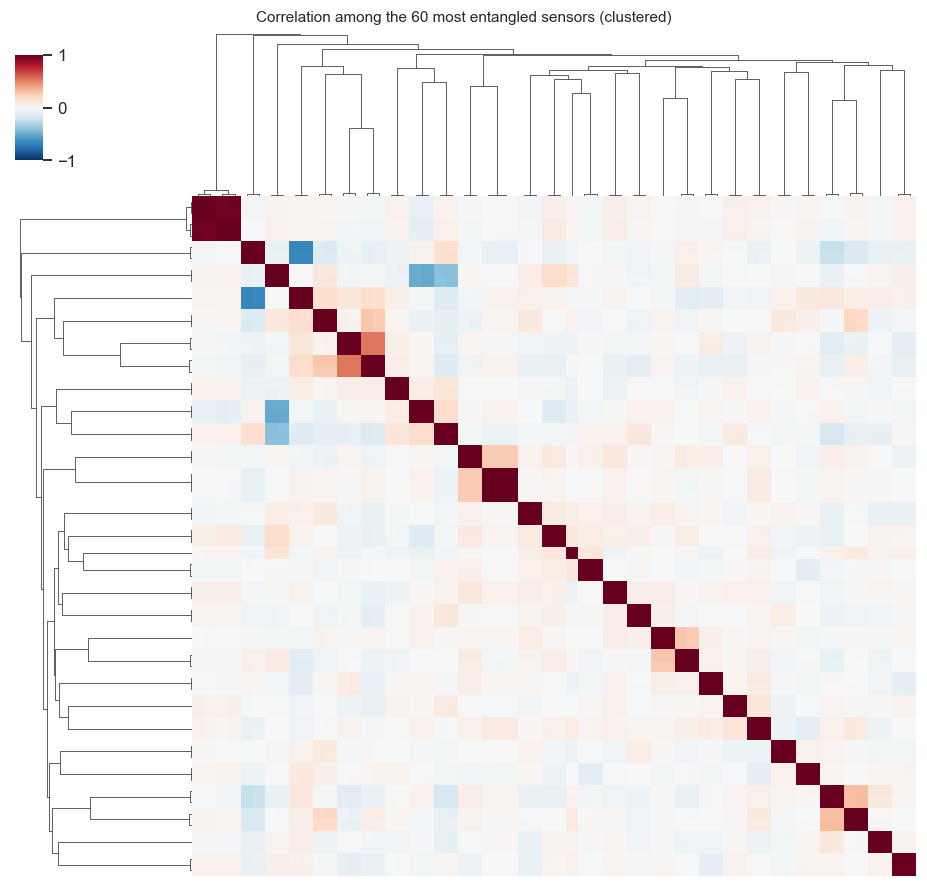

strongest partner correlation within this subset: 1.000
weakest  strongest-partner in this subset       : 0.998


In [32]:
# Show the block structure directly: take the sensors most entangled with a partner,
# not the most variable ones - high variance does not imply membership of a block.
K_BLOCK = 60
block_members = (abs_corr.max()               # each sensor's strongest partner
                         .sort_values(ascending=False)
                         .head(K_BLOCK).index.tolist())
sub = train[block_members].corr()

g = sns.clustermap(sub, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                   figsize=(8.5, 8), xticklabels=False, yticklabels=False,
                   cbar_pos=(0.02, 0.83, 0.03, 0.12))
g.figure.suptitle(f"Correlation among the {K_BLOCK} most entangled sensors (clustered)",
                  y=1.0, fontsize=10)
plt.show()

print(f"strongest partner correlation within this subset: "
      f"{abs_corr.loc[block_members, block_members].max().max():.3f}")
print(f"weakest  strongest-partner in this subset       : "
      f"{abs_corr.max().sort_values(ascending=False).head(K_BLOCK).min():.3f}")

A near-zero median |r| alongside a large "has a partner above 0.9" count is the signature of **block
structure**: most pairs unrelated, redundancy concentrated in tight groups — almost certainly sensors
on the same tool or process step. Consequences: plain logistic coefficients will be unstable (weight
splits arbitrarily within a block, so use L2/elastic-net); tree importance will be diluted across
block members; and effective dimensionality is far below the raw count, which helps given only 87
failures. Block correlation is *positive* dependence, under which the BH correction in §3 stays
valid.

## 6. Saved outputs

Three descriptive tables go to `../outputs/`. They record what the data looks like, not which
features the model gets, so reading them later leaks no selection decision. The test file has fewer
rows than the profile file: constant sensors are profiled but not tested.

| File | Contents |
|---|---|
| `eda_sensor_profiles.csv` | mean, SD, skew, kurtosis, CV, n_unique |
| `eda_sensor_tests.csv` | AUC, group medians, raw and FDR p-value |
| `eda_missing_flags.csv` | affected units, both failure rates, lift |

In [15]:
OUT.mkdir(parents=True, exist_ok=True)

# 1. Per-sensor numeric profile (§2)
profiles_out = prof.copy()
profiles_out.index.name = "sensor"
profiles_out = profiles_out.reset_index()

# 2. Per-sensor test results, most significant first (§3)
tests_out = (tests[["sensor", "auc", "auc_signed", "median_fail", "median_pass",
                    "p", "p_fdr"]]
             .sort_values(["p_fdr", "auc_signed"], ascending=[True, False])
             .reset_index(drop=True))
tests_out["significant_fdr"] = tests_out.p_fdr < ALPHA
tests_out.insert(0, "rank", tests_out.index + 1)

# 3. Missing-value flag lifts (§3.1)
flags_out = flags_df.copy()

files = {
    "eda_sensor_profiles.csv": profiles_out,
    "eda_sensor_tests.csv":    tests_out,
    "eda_missing_flags.csv":   flags_out,
}
for name, df in files.items():
    df.to_csv(OUT / name, index=False)
    print(f"saved {OUT / name}   ({len(df):>4} rows x {df.shape[1]} cols)")

print(f"\nsensors significant after FDR correction: {int(tests_out.significant_fdr.sum())}"
      f" of {len(tests_out)}")
print("\nTop 10 sensors by rank:")
display(tests_out.head(10).round(4))

saved ..\outputs\eda_sensor_profiles.csv   ( 436 rows x 10 cols)
saved ..\outputs\eda_sensor_tests.csv   ( 436 rows x 9 cols)
saved ..\outputs\eda_missing_flags.csv   (  28 rows x 5 cols)

sensors significant after FDR correction: 20 of 436

Top 10 sensors by rank:


,rank,sensor,auc,auc_signed,median_fail,median_pass,p,p_fdr,significant_fdr
0,1,S059,0.7281,0.2281,8.5273,1.1677,0.0000,0.0000,True
1,2,S247,0.6556,0.1556,0.0343,0.0274,0.0000,0.0002,True
2,3,S519,0.6511,0.1511,7.3813,5.9227,0.0000,0.0002,True
3,4,S103,0.6458,0.1458,-0.0081,-0.0099,0.0000,0.0006,True
4,5,S510,0.6312,0.1312,61.3699,48.1474,0.0000,0.0036,True
5,6,S477,0.6300,0.1300,6.3640,5.2977,0.0001,0.0036,True
6,7,S205,0.6290,0.1290,9.3300,7.8200,0.0001,0.0036,True
7,8,S290,0.6276,0.1276,0.1166,0.0833,0.0001,0.0038,True
8,9,S341,0.6246,0.1246,2.7764,2.4068,0.0001,0.0050,True
9,10,S385,0.6194,0.1194,0.0072,0.0068,0.0001,0.0064,True


## 7. Summary

**The data.** 1,253 units, 436 sensors, 6.9% failures. Skewed, heavy-tailed, wildly different scales,
organised into correlated blocks.

**The signal.** Weak but real. A few sensors clear FDR and the best beats a permutation null, but AUC
piles up at 0.5 and no single sensor separates the classes. Several missing-value flags show a clear
failure-rate lift.

| Decision for modelling | Evidence |
|---|---|
| Scale inside the pipeline | §2 — SDs span orders of magnitude |
| Use PR-AUC and recall, not accuracy | §2.1 — always-pass scores 93.1% |
| Regularised or ensemble models | §3, §5 — weak distributed signal, correlated predictors |
| Time-ordered cross-validation | §2.1 — sequential units, failures cluster |
| Keep the missing-value flags | §3.1 — several carry real lift |
| Benchmark against the best single sensor | §3 — per-sensor AUC is on the model's scale |
| Try dispersion-based features | §4 — failures are more scattered, not just shifted |

